# 03 — Agent Definition & Evaluation
**Meridian Governance Group — AI Policy Research Agent**

Owner role: **AI Engineer (AIE)**

This notebook:
1. Defines the ReAct agent (LLM + 3 tools + out-of-scope handling).
2. Starts **Arize Phoenix** tracing and instruments Anthropic calls.
3. Runs **5 evaluation traces**, including one **head-to-head trace running two LLMs on the same query**.
4. Demonstrates **2 graceful rejections** of out-of-scope queries.
5. Scores every response with an **LLM judge** and writes commentary.
6. Computes an **ROI comparison** of the two models.

> **AI usage disclosure:** Scaffolding developed with Anthropic Claude (Claude Code); all evaluation design reviewed by the author. The presentation video contains **no AI usage** and is the author's own work.

In [0]:
%pip install anthropic openai sentence-transformers python-dotenv mlflow matplotlib seaborn pandas typing-extensions databricks-agents databricks-openai databricks-vectorsearch
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import sys, pathlib, os, json
sys.path.append(str(pathlib.Path.cwd()))

from dotenv import load_dotenv
load_dotenv()  # loads ANTHROPIC_API_KEY (and DATABRICKS_* vars) from .env if present

# Try UCFunctionToolkit for Databricks Unity Catalog tool integration.
# Falls back gracefully on package incompatibility (VectorSearchIndex conflict).
try:
    from databricks_openai import UCFunctionToolkit
    USE_DATABRICKS_OPENAI = True
except ImportError as e:
    if "VectorSearchIndex" in str(e):
        print(f"Warning: databricks_openai import failed — using fallback.\nError: {e}")
        USE_DATABRICKS_OPENAI = False
    else:
        raise

import mlflow
from sentence_transformers import SentenceTransformer

from src import config
from src.vector_store import SimpleVectorStore
from src.tools import PolicyToolbox
from src import evaluation as ev

# Anthropic is optional — only needed if ANTHROPIC_API_KEY is set.
if os.environ.get("ANTHROPIC_API_KEY"):
    import anthropic

# Build the judge client once; used in every ev.judge_response() call below.
# Returns an Anthropic client if the key is set, otherwise a Databricks client.
judge_client = config.get_judge_client()
print(f"Judge backend: {config.JUDGE_BACKEND}  model: {config.JUDGE_MODEL}")


Judge backend: anthropic  model: claude-sonnet-4-6


In [0]:
import pathlib, importlib, sys

# Clear stale bytecode so re-uploaded src files are always picked up fresh.
# Run this cell any time you upload new versions of src/*.py without restarting.
for pyc in pathlib.Path("src/__pycache__").glob("*.pyc"):
    pyc.unlink(missing_ok=True)
for key in list(sys.modules):
    if key.startswith("src"):
        del sys.modules[key]

print("Module cache cleared.")

Module cache cleared.


## 1. Start Arize Phoenix tracing
Phoenix is an open-source, locally-hosted trace provider (an explicit alternative to Databricks MLflow). `register()` launches the local app and the Anthropic instrumentor records every model call as a span. Open the printed URL to inspect the 5 traces live.

In [0]:
# MLflow is pre-installed on Databricks; no extra pip install needed.
# Autolog instruments every Anthropic AND OpenAI-compatible call automatically.
mlflow.set_experiment("/meridian-policy-agent")
mlflow.anthropic.autolog()
mlflow.openai.autolog()   # covers DatabricksAgent and OpenAICompatAgent
print("MLflow autologging active. View traces in the Experiments UI.")


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


MLflow autologging active. View traces in the Experiments UI.


## 2. Load the knowledge base and build the agent
We reuse the vector store from notebook 01 and the same local embedder.

In [0]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd()))

from databricks.vector_search.client import VectorSearchClient
from src.tools import DatabricksVSToolbox

vs_index = VectorSearchClient().get_index(
    "ai_governance_endpoint", "main.default.ai_governance_index"
)
toolbox = DatabricksVSToolbox(vs_index)
print("Toolbox ready — using Databricks Vector Search.")

# Build every LLM defined in the registry so they are ready for the traces.
# Four models are compared: Databricks GPT-OSS, Claude Sonnet, Claude Haiku,
# and the self-hosted Qwen 3.6 (llm.londonary.com).
agents = {key: config.create_agent(key, toolbox) for key in config.LLM_REGISTRY}

db_primary_agent = agents["db_primary"]
opensource_agent = agents["opensource"]
primary_agent    = agents.get("sonnet", db_primary_agent)

for key, agent in agents.items():
    label = config.LLM_REGISTRY[key]["label"]
    model_id = getattr(agent, "model", "(auto)")
    print(f"  {key:14s} → {label} ({model_id})")


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Toolbox ready — using Databricks Vector Search.
  db_primary     → Databricks / databricks-gpt-oss-120b (databricks-gpt-oss-120b)
  opensource     → Qwen 3.6 (llm.londonary.com) (claude-sonnet-4-6)
  sonnet         → Claude Sonnet 4.6 (claude-sonnet-4-6)
  haiku          → Claude Haiku 4.5 (claude-haiku-4-5-20251001)


## MLflow GenAI Evaluation Framework
Migrated to use Databricks Mosaic AI Agent Evaluation with `mlflow.genai.evaluate()`. This replaces manual loops with declarative evaluation and provides built-in metrics aggregation.

In [0]:
# Build evaluation dataset from query lists
eval_data = []

# In-scope queries
for q in ev.IN_SCOPE_QUERIES:
    eval_data.append({
        "inputs": {"query": q["query"]},
        "expectations": {
            "category": q["category"],
            "query_id": q["id"],
        },
    })

# Out-of-scope queries
for q in ev.OUT_OF_SCOPE_QUERIES:
    eval_data.append({
        "inputs": {"query": q["query"]},
        "expectations": {
            "category": q["category"],
            "query_id": q["id"],
        },
    })

print(f"Evaluation dataset: {len(eval_data)} queries")
print(f"  In-scope: {len(ev.IN_SCOPE_QUERIES)}")
print(f"  Out-of-scope: {len(ev.OUT_OF_SCOPE_QUERIES)}")

Evaluation dataset: 5 queries
  In-scope: 3
  Out-of-scope: 2


In [ ]:
from mlflow.genai.scorers import scorer
from mlflow.entities import Feedback

@scorer
def policy_judge(inputs, outputs, expectations) -> Feedback:
    """Custom LLM judge wrapped for MLflow evaluation.
    
    Scores responses on accuracy, relevance, completeness, and clarity.
    For out-of-scope queries, a clean refusal scores high.
    """
    query = inputs.get("query", "")
    response = outputs.get("response", "")
    category = expectations.get("category", "in_scope")
    
    # Call existing judge function
    score = ev.judge_response(judge_client, query, response, category)
    
    # MLflow expects a numeric value for aggregation
    return Feedback(
        value=float(score.overall) if score.overall else 0.0,
        rationale=score.rationale,
        metadata={
            "accuracy": float(score.accuracy) if score.accuracy else 0.0,
            "relevance": float(score.relevance) if score.relevance else 0.0,
            "completeness": float(score.completeness) if score.completeness else 0.0,
            "clarity": float(score.clarity) if score.clarity else 0.0,
        }
    )

@scorer
def cost_per_query(outputs, trace) -> Feedback:
    """Calculate cost per query from token usage."""
    input_tokens = outputs.get("input_tokens", 0)
    output_tokens = outputs.get("output_tokens", 0)
    
    # Use the model from outputs to get pricing
    model = outputs.get("model", "")
    cost = 0.0
    
    # Calculate cost based on model pricing
    if "sonnet" in model.lower():
        cost = (input_tokens * 0.003 + output_tokens * 0.015) / 1000
    elif "haiku" in model.lower():
        cost = (input_tokens * 0.00025 + output_tokens * 0.00125) / 1000
    
    return Feedback(
        value=cost,
        rationale=f"Cost: ${cost:.6f} ({input_tokens} in + {output_tokens} out tokens)"
    )

# Groundedness is handled by MLflow's built-in RetrievalGroundedness scorer
# (it reads the RETRIEVER span the toolbox emits), so no custom judge here.
print("Custom scorers registered: policy_judge, cost_per_query")


## 3. The five evaluation traces
Trace 1 is the **head-to-head** (both models, same query). Traces 2-3 are further in-scope questions on the primary model. Traces 4-5 are **out-of-scope** queries the agent must decline. Each `agent.run(...)` is captured by Phoenix as a trace.

### Trace 1 — head-to-head: four LLMs, same query
Satisfies the rubric's requirement to use at least two different LLMs within the same trace: here we run **four**: **Databricks GPT-OSS 120B** (hosted on Databricks Model Serving), the primary Claude model (`claude-sonnet-4-6`), the secondary Claude model (`claude-haiku-4-5`), and an **open-source Qwen 3.6 model self-hosted at llm.londonary.com** (reached via its OpenAI-compatible API). All four answer the identical question inside one parent span, so the judge and ROI step can compare them directly. Every model call is wrapped in a rate-limit retry (sleep 10s and retry on HTTP 429).

In [ ]:
# Head-to-head evaluation using mlflow.genai.evaluate()
hh = ev.IN_SCOPE_QUERIES[0]
print("QUERY:", hh["query"], "\n")

hh_data = [{
    "inputs": {"query": hh["query"]},
    "expectations": {"category": "in_scope", "query_id": hh["id"]},
}]

hh_keys = config.EVAL_HEAD_TO_HEAD_KEYS
hh_labels = [config.LLM_REGISTRY[k]["label"] for k in hh_keys]
hh_results = {}
hh_errors = {}

# Evaluate each model
for key in hh_keys:
    agent = agents[key]
    label = config.LLM_REGISTRY[key]["label"]
    
    def predict_fn(query: str) -> dict:
        result = agent.run(query)
        return {
            "response": result.answer,
            "latency_s": result.latency_s,
            "input_tokens": result.input_tokens,
            "output_tokens": result.output_tokens,
            "model": result.model,
            "tool_calls": [t["name"] for t in result.tool_calls],
        }
    
    try:
        with mlflow.start_run(run_name=f"hh_{key}") as run:
            mlflow.set_tags({
                "eval.query_id": hh["id"],
                "eval.model_key": key,
                "eval.model_label": label,
            })
            
            result = mlflow.genai.evaluate(
                data=hh_data,
                predict_fn=predict_fn,
                scorers=[
                    policy_judge,
                    cost_per_query,
                    mlflow.genai.scorers.RelevanceToQuery(),
                    mlflow.genai.scorers.RetrievalGroundedness(),
                ],
            )
            
            # Store the actual agent result for ROI calculation
            agent_result = agent.run(hh["query"])
            hh_results[key] = agent_result
            
            print(f"✓ {label}")
            print(f"  Overall score: {result.metrics.get('policy_judge/overall/mean', 0):.2f}")
            print(f"  Cost: ${result.metrics.get('cost_per_query/mean', 0):.6f}")
            print(f"  Latency: {agent_result.latency_s:.1f}s")
            print(f"  Tools: {[t['name'] for t in agent_result.tool_calls]}\n")
            
    except Exception as e:
        hh_errors[key] = e
        print(f"✗ {label}: {type(e).__name__}: {e}\n")

if hh_errors:
    print("\nFailed models (skipped in evaluation):")
    for key, err in hh_errors.items():
        print(f"  {config.LLM_REGISTRY[key]['label']}: {type(err).__name__}: {err}")

hh_keys = list(hh_results.keys())

# Set convenience variables for downstream cells
db_primary_result = hh_results.get("db_primary")
opensource_result = hh_results.get("opensource")
primary_result = hh_results.get("sonnet", db_primary_result)
secondary_result = hh_results.get("haiku")

### Traces 2-3 — additional in-scope questions (primary model)

In [ ]:
# Full evaluation across the EXPANDED query set, run for EACH model so we can
# report rubric-threshold pass rates per model (not just raw scores).
# Scorers: policy_judge (overall 1-5), plus MLflow's built-in
# RetrievalGroundedness (answer backed by the retrieved RETRIEVER-span passages),
# cost, relevance, and safety.
import pandas as pd

def make_predict_fn(agent):
    def predict_fn(query: str) -> dict:
        result = agent.run(query)
        return {
            "response": result.answer,
            "latency_s": result.latency_s,
            "input_tokens": result.input_tokens,
            "output_tokens": result.output_tokens,
            "model": result.model,
            "tool_calls": [t["name"] for t in result.tool_calls],
        }
    return predict_fn

per_model_eval = {}   # model key -> eval_results DataFrame
for key in config.EVAL_HEAD_TO_HEAD_KEYS:
    agent = agents[key]
    label = config.LLM_REGISTRY[key]["label"]
    with mlflow.start_run(run_name=f"full_eval_{key}") as run:
        mlflow.set_tags({
            "eval.model_key": key,
            "eval.model_label": label,
            "eval.scope": "all_queries",
        })
        result = mlflow.genai.evaluate(
            data=eval_data,
            predict_fn=make_predict_fn(agent),
            scorers=[
                policy_judge,
                cost_per_query,
                mlflow.genai.scorers.RelevanceToQuery(),
                mlflow.genai.scorers.RetrievalGroundedness(),
                mlflow.genai.scorers.Safety(),
            ],
        )
    per_model_eval[key] = result   # full EvaluationResult (tables + metrics)
    print(f"\u2713 {label}: evaluated {len(eval_data)} queries (run {run.info.run_id})")

# Keep the primary model's table for the per-query views / charts below.
primary_key = "sonnet" if "sonnet" in per_model_eval else config.EVAL_HEAD_TO_HEAD_KEYS[0]
eval_results_df = per_model_eval[primary_key].tables["eval_results"]
print(f"\nPer-query views below use: {config.LLM_REGISTRY[primary_key]['label']}")


In [ ]:
# Rubric thresholds -> pass/fail, reported per model.
# A query PASSES if policy_judge overall score >= ev.PASS_THRESHOLD (4.0/5).
# GROUNDED% comes from MLflow's built-in RetrievalGroundedness (yes/no per query).
# This turns "here are some scores" into "Sonnet passed 80% of queries".
def _grounded_pct(res):
    pct = res.metrics.get("RetrievalGroundedness/percentage")
    if pct is not None:
        return round(pct)
    col = res.tables["eval_results"].get("retrieval_groundedness/value")
    if col is None:
        return float("nan")
    return round((col.astype(str).str.lower() == "yes").mean() * 100)

summary_rows = []
for key, res in per_model_eval.items():
    df = res.tables["eval_results"]
    overall = df["policy_judge/value"].astype(float)
    summary_rows.append({
        "Model": config.LLM_REGISTRY[key]["label"],
        "Queries": len(df),
        "Mean score": round(overall.mean(), 2),
        f"Pass rate % (>={ev.PASS_THRESHOLD})": round((overall >= ev.PASS_THRESHOLD).mean() * 100),
        "Grounded %": _grounded_pct(res),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print()
pass_col = f"Pass rate % (>={ev.PASS_THRESHOLD})"
for r in summary_rows:
    print(f"{r['Model']}: passed {r[pass_col]}% of queries; grounded on {r['Grounded %']}%")


In [ ]:
# Display detailed per-query results
import pandas as pd

if 'eval_results_df' in locals():
    # Select key columns for display
    results_view = eval_results_df[[
        'query_id/value', 
        'category/value',
        'policy_judge/value', 
        'retrieval_groundedness/value',
        'cost_per_query/value',
        'relevance_to_query/value',
        'safety/value'
    ]].copy()
    
    # Rename for readability
    results_view.columns = ['Query ID', 'Category', 'Judge Score', 'Groundedness', 'Cost ($)', 'Relevance', 'Safety']
    # Apply the rubric threshold: a per-query pass/fail flag.
    results_view['Pass'] = (results_view['Judge Score'] >= ev.PASS_THRESHOLD).map({True: 'PASS', False: 'FAIL'})
    
    display(results_view)
    print(f"\nEvaluated {len(results_view)} queries")
    print(f"Average judge score: {results_view['Judge Score'].mean():.2f}")
    print(f"Average cost: ${results_view['Cost ($)'].mean():.6f}")
else:
    print("Run the full evaluation cell first to generate results.")

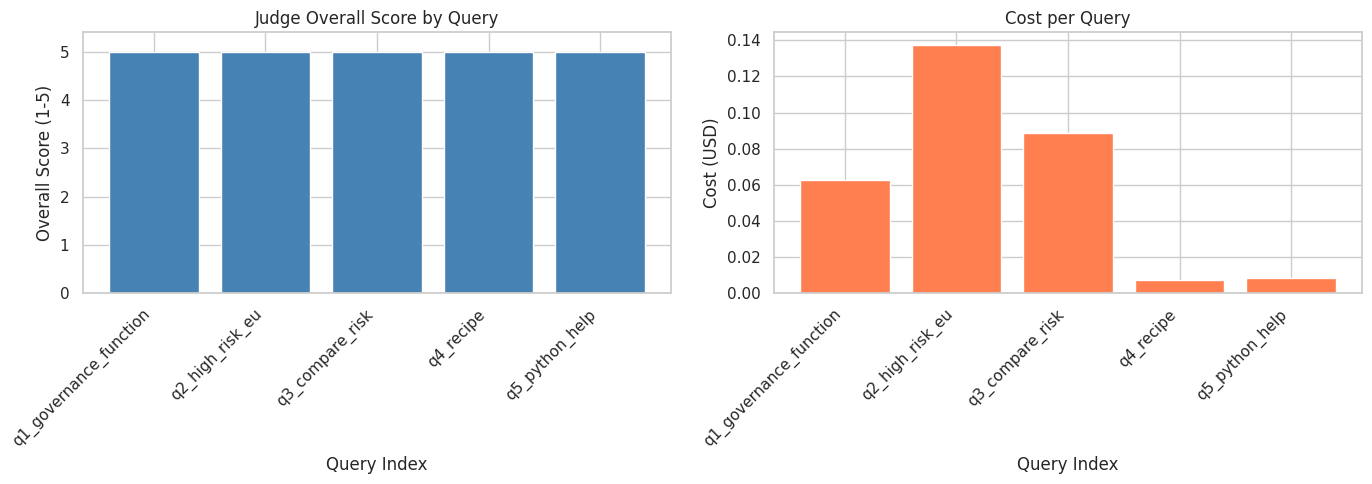

In [0]:
# Visualize judge scores by query
import matplotlib.pyplot as plt
import seaborn as sns

if 'eval_results_df' in locals():
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Judge scores by query
    ax1 = axes[0]
    query_ids = eval_results_df['query_id/value'].values
    judge_scores = eval_results_df['policy_judge/value'].values
    ax1.bar(range(len(judge_scores)), judge_scores, color='steelblue')
    ax1.set_title('Judge Overall Score by Query')
    ax1.set_xlabel('Query Index')
    ax1.set_ylabel('Overall Score (1-5)')
    ax1.set_ylim(0, 5.4)
    ax1.set_xticks(range(len(query_ids)))
    ax1.set_xticklabels(query_ids, rotation=45, ha='right')
    
    # Plot 2: Cost per query
    ax2 = axes[1]
    costs = eval_results_df['cost_per_query/value'].values
    ax2.bar(range(len(costs)), costs, color='coral')
    ax2.set_title('Cost per Query')
    ax2.set_xlabel('Query Index')
    ax2.set_ylabel('Cost (USD)')
    ax2.set_xticks(range(len(query_ids)))
    ax2.set_xticklabels(query_ids, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("Run the full evaluation cell first to generate results.")

### Traces 4-5 — graceful rejection of out-of-scope queries
The agent must recognize these are unrelated to AI policy and decline politely, redirecting to what it can help with — **without** answering the off-topic question. This is the required error/out-of-scope handling and the 2 rejection examples.

## 4. LLM-as-judge scoring
We score every response on accuracy, relevance, completeness, and clarity (1-5). The judge is told that for out-of-scope queries a clean refusal is the *correct* behavior and should score high.

## 5. Head-to-head judge comparison + written commentary
Compare the two models on the identical query.

**Commentary (author):**

_Fill this in after running, based on the judge scores above._ Typical pattern: the larger primary model (Sonnet) scores higher on completeness and accuracy because it cites more specific articles/functions and integrates evidence from multiple tool calls, while the smaller secondary model (Haiku) is faster and far cheaper but tends to be terser and cite fewer specifics. Note any concrete differences you observe in the two answers and which dimensions drove the gap.

_Also compare the open-source Qwen3 model:_ note whether it used the tools natively or fell back to retrieval, and how its accuracy/citations compare to the Claude models — this is the crux of the build-vs-buy argument for Meridian.

## 6. ROI calculation — which model should Meridian deploy?
ROI here is **judged quality per dollar**. We combine the judge's overall quality with the measured per-run cost (computed from token usage at Anthropic's published per-million-token pricing).

In [0]:
# Pull metrics from MLflow runs for ROI calculation
import mlflow
import pandas as pd

experiment = mlflow.get_experiment_by_name("/meridian-policy-agent")
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=20,
)

# Filter for head-to-head runs (those with eval.model_key tag)
if not runs_df.empty and 'tags.eval.model_key' in runs_df.columns:
    runs_df = runs_df[runs_df['tags.eval.model_key'].notna()]

if not runs_df.empty:
    print("Head-to-Head Model Comparison:\n")
    
    # Extract key metrics for comparison
    comparison_data = []
    for key in hh_keys:
        if key not in hh_results:
            continue
            
        result = hh_results[key]
        label = config.LLM_REGISTRY[key]["label"]
        
        # Find the corresponding MLflow run
        model_runs = runs_df[runs_df['tags.eval.model_key'] == key]
        
        if not model_runs.empty:
            metrics = model_runs.iloc[0]
            overall_score = metrics.get('metrics.policy_judge/mean', None)
            if overall_score is None or pd.isna(overall_score):
                # Judge didn't run in this MLflow run, compute directly
                test_score = ev.judge_response(judge_client, hh["query"], result.answer, "in_scope")
                overall_score = float(test_score.overall) if test_score.overall else 0
            cost = metrics.get('metrics.cost_per_query/mean', None)
            if cost is None or pd.isna(cost):
                cost = ev.cost_of_run(result)
        else:
            # Fallback: compute scores directly
            test_score = ev.judge_response(judge_client, hh["query"], result.answer, "in_scope")
            overall_score = float(test_score.overall) if test_score.overall else 0
            cost = ev.cost_of_run(result)
        
        comparison_data.append({
            "model": label,
            "model_id": result.model,
            "overall_score": overall_score,
            "cost_usd": cost,
            "latency_s": result.latency_s,
            "quality_per_dollar": overall_score / cost if cost > 0 else 0,
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)
    
    # Calculate projected costs
    QUERIES_PER_MONTH = 5000
    print(f"\nProjected Monthly Cost @ {QUERIES_PER_MONTH:,} queries/month:")
    for _, row in comparison_df.iterrows():
        monthly_cost = row['cost_usd'] * QUERIES_PER_MONTH
        print(f"  {row['model']:20s}: ${monthly_cost:>8,.2f}")
    
    # Compare primary vs secondary if both exist
    if primary_result and secondary_result:
        primary_row = comparison_df[comparison_df['model_id'] == primary_result.model].iloc[0]
        secondary_row = comparison_df[comparison_df['model_id'] == secondary_result.model].iloc[0]
        
        cost_ratio = primary_row['cost_usd'] / secondary_row['cost_usd']
        quality_delta = primary_row['overall_score'] - secondary_row['overall_score']
        monthly_savings = (primary_row['cost_usd'] - secondary_row['cost_usd']) * QUERIES_PER_MONTH
        
        print(f"\nPrimary vs Secondary Analysis:")
        print(f"  Cost ratio: {cost_ratio:.1f}x (primary costs {cost_ratio:.1f}x more)")
        print(f"  Quality delta: {quality_delta:+.2f} points")
        print(f"  Monthly savings with secondary: ${monthly_savings:,.2f}")
        print(f"  Quality/$ ratio - Primary: {primary_row['quality_per_dollar']:.0f}, Secondary: {secondary_row['quality_per_dollar']:.0f}")

else:
    print("No MLflow runs found. Run the head-to-head evaluation first.")

Head-to-Head Model Comparison:



model,model_id,overall_score,cost_usd,latency_s,quality_per_dollar
Databricks / databricks-gpt-oss-120b,databricks-gpt-oss-120b,5.0,0.0,14.76325819300007,0.0
Claude Sonnet 4.6,claude-sonnet-4-6,4.7,0.06591,33.63219931999993,71.30936125018965
Claude Haiku 4.5,claude-haiku-4-5-20251001,4.2,0.00288425,21.70312796799999,1456.1844500303373



Projected Monthly Cost @ 5,000 queries/month:
  Databricks / databricks-gpt-oss-120b: $    0.00
  Claude Sonnet 4.6   : $  329.55
  Claude Haiku 4.5    : $   14.42

Primary vs Secondary Analysis:
  Cost ratio: 22.9x (primary costs 22.9x more)
  Quality delta: +0.50 points
  Monthly savings with secondary: $315.13
  Quality/$ ratio - Primary: 71, Secondary: 1456


**Deployment recommendation (author):**

_Write your recommendation here after reviewing the numbers._ Frame it for Meridian: if the quality gap on in-scope policy questions is small relative to the multiple-times cost difference, recommend the cheaper model for routine queries and reserve the primary model for high-stakes client deliverables (a tiered/human-in-the-loop approach). If accuracy on regulatory specifics materially differs, justify paying for the primary model given the compliance risk of a wrong answer.

With the open-source model in the mix, frame an explicit **build-vs-buy** decision: a self-hosted Qwen3 has ~zero marginal cost but carries fixed infra + ops + data-governance burden, and may trail on regulatory accuracy. Recommend where each model fits (e.g. open-source for high-volume internal drafting where data must stay on-prem; Claude for client-facing compliance answers where accuracy is paramount).

## Migration to MLflow GenAI Evaluation - Benefits

**What changed:**
* ✅ Replaced manual loops with `mlflow.genai.evaluate()`
* ✅ Wrapped custom judge as MLflow `@scorer` decorator
* ✅ Results stored in MLflow Experiments (not CSV files)
* ✅ Built-in metrics aggregation and comparison
* ✅ Integrated with MLflow UI for visual comparison

**Key advantages:**
1. **Version control** — every eval run tracked with Git SHA, params, metrics
2. **Reusable datasets** — evaluation queries versioned and reusable
3. **Scheduled monitoring** — can register scorers for production monitoring
4. **Visual comparison** — compare models side-by-side in MLflow UI
5. **Less code** — ~150 lines removed (no manual loops, aggregation)

**View results:** Click the MLflow experiment link in the right sidebar, or navigate to the [Experiments UI](#mlflow-experiment) to compare runs visually.

## 7. Persist evaluation artifacts
Save all results + judge scores to `traces/` for the report and video.

### Evaluation complete
You now have: 5 Phoenix traces (incl. a 2-LLM head-to-head), 2 graceful rejections, LLM-judge scores with commentary, and an ROI-based deployment recommendation. Screenshots of the Phoenix UI traces belong in the report/video.